In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Upload/Asthma Dectection Data.csv')
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,7421,43,1,0,2,29.059613,0,3.019854,6.119637,8.300960,...,3.125249,5.166032,0,1,0,0,0,1,1,Dr_Confid
7172,7422,18,1,0,1,20.740850,0,5.805180,4.386992,7.731192,...,1.132977,5.509502,0,0,0,1,1,0,1,Dr_Confid
7173,7423,54,0,3,2,37.079560,0,4.735169,8.214064,7.483521,...,1.685962,3.346877,1,0,1,1,0,1,1,Dr_Confid
7174,7424,46,1,0,2,23.444712,0,9.672637,7.362861,6.717272,...,3.481549,1.713274,0,1,1,0,1,1,0,Dr_Confid


In [ ]:
df = df[['Age', 'Gender', 'BMI', 'Smoking', 'Wheezing',	'ShortnessOfBreath',	'ChestTightness',	'Coughing',	'NighttimeSymptoms',	'ExerciseInduced',	'Diagnosis']]
df

,Age,Gender,BMI,Smoking,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,15.848744,0,0,0,1,0,0,1,0
1,26,1,22.757042,0,1,0,0,1,1,1,0
2,57,0,18.395396,0,1,1,1,0,1,1,0
3,40,1,38.515278,0,1,0,1,1,1,0,0
4,61,0,19.283802,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,29.059613,0,0,1,0,0,0,1,1
7172,18,1,20.740850,0,0,0,0,1,1,0,1
7173,54,0,37.079560,0,1,0,1,1,0,1,1
7174,46,1,23.444712,0,0,1,1,0,1,1,0


In [ ]:
df.to_csv('general.csv', index=False)

In [ ]:
data = pd.read_csv('/content/general.csv')
data

,Age,Gender,BMI,Smoking,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,15.848744,0,0,0,1,0,0,1,0
1,26,1,22.757042,0,1,0,0,1,1,1,0
2,57,0,18.395396,0,1,1,1,0,1,1,0
3,40,1,38.515278,0,1,0,1,1,1,0,0
4,61,0,19.283802,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,29.059613,0,0,1,0,0,0,1,1
7172,18,1,20.740850,0,0,0,0,1,1,0,1
7173,54,0,37.079560,0,1,0,1,1,0,1,1
7174,46,1,23.444712,0,0,1,1,0,1,1,0


In [ ]:
# 3. Handle missing values (optional – based on your dataset)
data.fillna(data.median(numeric_only=True), inplace=True)

In [ ]:
# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

# Clinical

In [ ]:
df = df[['Age', 'Gender', 'BMI', 'LungFunctionFEV1',	'LungFunctionFVC', 'Smoking', 'Wheezing',	'ShortnessOfBreath',	'ChestTightness',	'Coughing',	'NighttimeSymptoms',	'ExerciseInduced',	'Diagnosis']]
df

,Age,Gender,BMI,LungFunctionFEV1,LungFunctionFVC,Smoking,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,15.848744,1.369051,4.941206,0,0,0,1,0,0,1,0
1,26,1,22.757042,2.197767,1.702393,0,1,0,0,1,1,1,0
2,57,0,18.395396,1.698011,5.022553,0,1,1,1,0,1,1,0
3,40,1,38.515278,3.032037,2.300159,0,1,0,1,1,1,0,0
4,61,0,19.283802,3.470589,3.067944,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,29.059613,3.125249,5.166032,0,0,1,0,0,0,1,1
7172,18,1,20.740850,1.132977,5.509502,0,0,0,0,1,1,0,1
7173,54,0,37.079560,1.685962,3.346877,0,1,0,1,1,0,1,1
7174,46,1,23.444712,3.481549,1.713274,0,0,1,1,0,1,1,0


In [ ]:
df = df.rename(columns={'LungFunctionFEV1': 'FEV1', 'LungFunctionFVC': 'FVC'})
df

,Age,Gender,BMI,FEV1,FVC,Smoking,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,15.848744,1.369051,4.941206,0,0,0,1,0,0,1,0
1,26,1,22.757042,2.197767,1.702393,0,1,0,0,1,1,1,0
2,57,0,18.395396,1.698011,5.022553,0,1,1,1,0,1,1,0
3,40,1,38.515278,3.032037,2.300159,0,1,0,1,1,1,0,0
4,61,0,19.283802,3.470589,3.067944,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,29.059613,3.125249,5.166032,0,0,1,0,0,0,1,1
7172,18,1,20.740850,1.132977,5.509502,0,0,0,0,1,1,0,1
7173,54,0,37.079560,1.685962,3.346877,0,1,0,1,1,0,1,1
7174,46,1,23.444712,3.481549,1.713274,0,0,1,1,0,1,1,0


In [ ]:
df['FEV1_FVC_ratio'] = df['FEV1'] / df['FVC']
df

,Age,Gender,BMI,FEV1,FVC,Smoking,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,FEV1_FVC_ratio
0,63,0,15.848744,1.369051,4.941206,0,0,0,1,0,0,1,0,0.277068
1,26,1,22.757042,2.197767,1.702393,0,1,0,0,1,1,1,0,1.290987
2,57,0,18.395396,1.698011,5.022553,0,1,1,1,0,1,1,0,0.338077
3,40,1,38.515278,3.032037,2.300159,0,1,0,1,1,1,0,0,1.318186
4,61,0,19.283802,3.470589,3.067944,0,1,1,1,0,0,1,0,1.131243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,29.059613,3.125249,5.166032,0,0,1,0,0,0,1,1,0.604961
7172,18,1,20.740850,1.132977,5.509502,0,0,0,0,1,1,0,1,0.205641
7173,54,0,37.079560,1.685962,3.346877,0,1,0,1,1,0,1,1,0.503742
7174,46,1,23.444712,3.481549,1.713274,0,0,1,1,0,1,1,0,2.032104


In [ ]:
df = df[['Age', 'Gender', 'BMI', 'FEV1',	'FVC', 'FEV1_FVC_ratio', 'Smoking', 'Wheezing',	'ShortnessOfBreath',	'ChestTightness',	'Coughing',	'NighttimeSymptoms',	'ExerciseInduced',	'Diagnosis']]
df

KeyError: "['FEV1_FVC_ratio'] not in index"

In [ ]:
df.to_csv('clinical.csv', index=False)

In [ ]:
df.to_csv('Asthma Detection Data.csv', index=False)

In [ ]:
data = pd.read_csv('/content/clinical.csv')
data

,Age,Gender,BMI,FEV1,FVC,Smoking,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,15.848744,1.369051,4.941206,0,0,0,1,0,0,1,0
1,26,1,22.757042,2.197767,1.702393,0,1,0,0,1,1,1,0
2,57,0,18.395396,1.698011,5.022553,0,1,1,1,0,1,1,0
3,40,1,38.515278,3.032037,2.300159,0,1,0,1,1,1,0,0
4,61,0,19.283802,3.470589,3.067944,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,29.059613,3.125249,5.166032,0,0,1,0,0,0,1,1
7172,18,1,20.740850,1.132977,5.509502,0,0,0,0,1,1,0,1
7173,54,0,37.079560,1.685962,3.346877,0,1,0,1,1,0,1,1
7174,46,1,23.444712,3.481549,1.713274,0,0,1,1,0,1,1,0


In [ ]:
# 3. Handle missing values (optional – based on your dataset)
data.fillna(data.median(numeric_only=True), inplace=True)

In [ ]:
# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

In [ ]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Assuming X is already defined as your features dataframe
cat_features = [i for i, col in enumerate(X.columns) if col in [
    'Gender', 'Smoking', 'Wheezing', 'ShortnessOfBreath',
    'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced'
]]

# Convert categorical columns to string
for col in X.columns[cat_features]:
    X[col] = X[col].astype(str)

In [ ]:
# Identify categorical columns (e.g., Gender, Smoking, etc.)
cat_features = [i for i, col in enumerate(X.columns) if col in ['Gender', 'Smoking', 'Wheezing',	'ShortnessOfBreath',	'ChestTightness',	'Coughing',	'NighttimeSymptoms',	'ExerciseInduced']]

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [ ]:
No i didnt check the code below.

data = pd.read_csv('/content/clinical.csv')

Columns are there : Age	Gender	BMI	FEV1	FVC	Smoking	Wheezing	ShortnessOfBreath	ChestTightness	Coughing	NighttimeSymptoms	ExerciseInduced	Diagnosis

# 3. Handle missing values (optional – based on your dataset)
data.fillna(data.median(numeric_only=True), inplace=True)

# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify categorical columns (e.g., Gender, Smoking, etc.)
cat_features = [i for i, col in enumerate(X.columns) if col in ['Gender', 'Smoking', 'Wheezing',	'ShortnessOfBreath',	'ChestTightness',	'Coughing',	'NighttimeSymptoms',	'ExerciseInduced']]

from catboost import CatBoostClassifier, Pool

# Initialize CatBoost
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    cat_features=cat_features,
    class_weights=[1,18],
    random_seed=42,
    verbose=100
)

# Train
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 11. Save model
joblib.dump(model, 'asthma_clinical_model_catboost.pkl')

SyntaxError: invalid syntax (<ipython-input-13-e17937d9c32f>, line 3)

In [ ]:
from catboost import CatBoostClassifier, Pool

In [ ]:
# Initialize CatBoost
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    cat_features=cat_features,
    class_weights=[1,18],
    random_seed=42,
    verbose=100
)

# Train
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)

0:	test: 0.6403193	best: 0.6403193 (0)	total: 55.7ms	remaining: 55.7s
100:	test: 0.9563837	best: 0.9563837 (100)	total: 1.09s	remaining: 9.67s
200:	test: 0.9663254	best: 0.9689348 (168)	total: 2.26s	remaining: 8.99s
300:	test: 0.9677739	best: 0.9695599 (271)	total: 3.38s	remaining: 7.85s
400:	test: 0.9646386	best: 0.9695599 (271)	total: 4.57s	remaining: 6.82s
500:	test: 0.9683593	best: 0.9695599 (271)	total: 5.5s	remaining: 5.48s
600:	test: 0.9715145	best: 0.9715145 (600)	total: 7.14s	remaining: 4.74s
700:	test: 0.9739255	best: 0.9742231 (676)	total: 8.89s	remaining: 3.79s
800:	test: 0.9741934	best: 0.9746994 (732)	total: 10.5s	remaining: 2.6s
900:	test: 0.9742827	best: 0.9749673 (873)	total: 11.5s	remaining: 1.27s
999:	test: 0.9759495	best: 0.9762174 (998)	total: 12.7s	remaining: 0us

bestTest = 0.9762174068
bestIteration = 998

Shrink model to first 999 iterations.


In [ ]:
# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

ROC AUC Score: 0.9762174068341469
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1362
           1       1.00      0.96      0.98        74

    accuracy                           1.00      1436
   macro avg       1.00      0.98      0.99      1436
weighted avg       1.00      1.00      1.00      1436



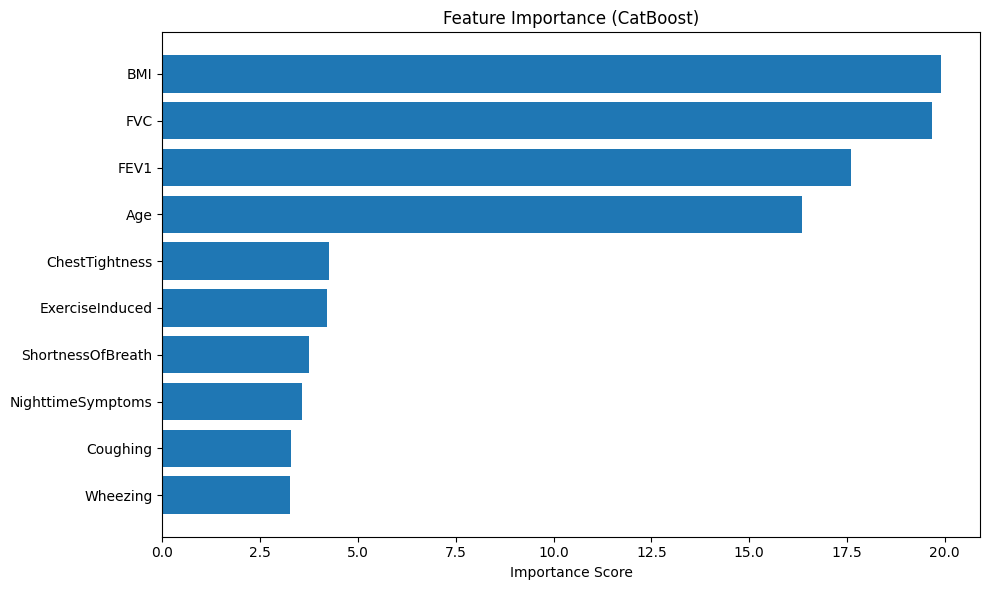

In [ ]:
import matplotlib.pyplot as plt
from catboost import Pool, CatBoostClassifier, cv, CatBoostRegressor, CatBoostRanker, CatBoostError, CatBoost

# Plot feature importance (Top 10)
feature_importances = model.get_feature_importance()
feature_names = X.columns

# Create DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title("Feature Importance (CatBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
# 11. Save model
#joblib.dump(model, 'asthma_clinical_model_XGB.pkl')
joblib.dump(model, 'test_asthma_clinical_model_catboost.pkl')
joblib.dump(model, 'strtype_asthma_clinical_model_catboost.pkl')

['strtype_asthma_clinical_model_catboost.pkl']

In [ ]:
# 11. Save model
#joblib.dump(model, 'asthma_clinical_model_XGB.pkl')
joblib.dump(model, 'asthma_clinical_model_catboost.pkl')

['asthma_clinical_model_catboost.pkl']

# Rule-Based ML Model

In [ ]:
class AsthmaPredictor:
    def __init__(self, model):
        self.model = model

    def rule_engine(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        if smoking == 1 and sob == 1 and coughing == 1:
            return 0.95
        if wheezing == 1 and nighttime == 1 and chest == 1:
            return 0.92
        if exercise == 1 and sob == 1:
            return 0.88
        if bmi >= 30 and sob == 1:
            return 0.87
        if age >= 60 and (sob == 1 or chest == 1):
            return 0.89
        if 18 <= age <= 40 and bmi < 28 and smoking == 1 and sob == 1:
            return 0.83
        if coughing == 1 and wheezing == 1:
            return 0.81
        if nighttime == 1 and coughing == 1:
            return 0.79
        if smoking == 1 and wheezing == 1 and chest == 1:
            return 0.85
        if 10 <= age <= 17 and exercise == 1 and coughing == 1:
            return 0.80
        if bmi < 25 and smoking == 0 and sob == 0 and coughing == 0 and wheezing == 0:
            return 0.10
        return 0.20

    def generate_advice(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        advice = []
        if smoking == 1:
            advice.append("Consider reducing or quitting smoking to improve respiratory health.")
        if bmi >= 30:
            advice.append("Maintaining a healthy BMI may reduce asthma-related risks.")
        if sob == 1:
            advice.append("Shortness of breath indicates possible airway issues—consider consulting a pulmonologist.")
        if exercise == 1 and sob == 1:
            advice.append("Avoid intense workouts until symptoms are under control.")
        if nighttime == 1 or coughing == 1:
            advice.append("Monitor nighttime symptoms and avoid allergens before sleep.")
        if wheezing == 1:
            advice.append("Wheezing may indicate airway inflammation—an inhaler might be helpful.")
        if chest == 1:
            advice.append("Persistent chest tightness should not be ignored—consider a medical checkup.")
        if not advice:
            advice.append("You're showing no major risk factors. Keep maintaining a healthy lifestyle!")
        return advice

    def predict(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        rule_prob = self.rule_engine(age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise)
        features = np.array([[age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise]])
        xgb_prob = self.model.predict_proba(features)[0][1]
        final_prob = round(0.6 * xgb_prob + 0.4 * rule_prob, 2)
        label = "High risk of Asthma" if final_prob >= 0.5 else "Low risk of Asthma"
        emoji = "✅" if label.startswith("Low") else "⚠️"
        advice_list = self.generate_advice(age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise)

        # Combine prediction and advice into one output string
        advice_text = "\n".join(advice_list)
        return f"{emoji} {label}. (Confidence: {final_prob:.2f})\n\nAdvice:\n{advice_text}"

In [ ]:
def predict(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        rule_prob = self.rule_engine(age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise)
        features = np.array([[age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise]])
        xgb_prob = self.model.predict_proba(features)[0][1]
        final_prob = round(0.6 * xgb_prob + 0.4 * rule_prob, 2)
        label = "High risk of Asthma" if final_prob >= 0.5 else "Low risk of Asthma"
        emoji = "✅" if label.startswith("Low") else "⚠️"
        advice_list = self.generate_advice(age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise)

        # Combine prediction and advice into one output string
        advice_text = "\n".join(advice_list)
        return f"{emoji} {label}. (Confidence: {final_prob:.2f})\n\nAdvice:\n{advice_text}"

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [ ]:
X, y = make_classification(n_samples=300, n_features=9, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [ ]:
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:19:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
predictor = AsthmaPredictor(xgb_model)

In [ ]:
import numpy as np

In [ ]:
test_output = predictor.predict(
    age=26,
    bmi=22.5,
    smoking=1,
    wheezing=0,
    nighttime=0,
    sob=1,
    chest=0,
    coughing=1,
    exercise=0
)

print("Prediction Result:\n", test_output)

Prediction Result:
 ⚠️ High risk of Asthma. (Confidence: 0.61)

Advice:
Consider reducing or quitting smoking to improve respiratory health.
Shortness of breath indicates possible airway issues—consider consulting a pulmonologist.
Monitor nighttime symptoms and avoid allergens before sleep.


In [ ]:
import joblib

In [ ]:
# 11. Save model
joblib.dump(predictor, 'asthma_pred_RB_model_XGB.pkl')

['asthma_pred_RB_model_XGB.pkl']

In [ ]:
# 11. Save model
joblib.dump(predictor, 'General(XGB).pkl')

['General(XGB).pkl']

In [ ]:
test_output = predictor.predict(
    age=26,
    bmi=18.5,
    smoking=1,
    wheezing=0,
    nighttime=0,
    sob=0,
    chest=0,
    coughing=1,
    exercise=0
)

print("Prediction Result:\n", test_output)

Prediction Result:
 ⚠️ High risk of Asthma. (Confidence: 0.55)

Advice:
Consider reducing or quitting smoking to improve respiratory health.
Monitor nighttime symptoms and avoid allergens before sleep.


In [ ]:
test_output = predictor.predict(
    age=30,
    bmi=19.5,
    smoking=0,
    wheezing=0,
    nighttime=0,
    sob=0,
    chest=0,
    coughing=0,
    exercise=0
)

print("Prediction Result:\n", test_output)

Prediction Result:
 ⚠️ High risk of Asthma. (Confidence: 0.53)

Advice:
You're showing no major risk factors. Keep maintaining a healthy lifestyle!


In [ ]:
test_output = predictor.predict(
    age=26,
    bmi=18.5,
    smoking=0,
    wheezing=0,
    nighttime=0,
    sob=0,
    chest=0,
    coughing=0,
    exercise=1
)

print("Prediction Result:\n", test_output)

Prediction Result:
 ⚠️ High risk of Asthma. (Confidence: 0.53)

Advice:
You're showing no major risk factors. Keep maintaining a healthy lifestyle!


In [ ]:
result, tips = predictor.predict(
    age=45, bmi=31, smoking=1, wheezing=1, nighttime=1,
    sob=1, chest=1, coughing=1, exercise=0
)

print(result)
for tip in tips:
    print("•", tip)

ValueError: too many values to unpack (expected 2)

In [ ]:
# Test the predictor before saving
test_output = predictor.predict(
    age=26,
    bmi=22.5,
    smoking=1,
    wheezing=0,
    nighttime=0,
    sob=1,
    chest=0,
    coughing=1,
    exercise=0
)

print("Prediction Result:", test_output)

Prediction Result: ⚠️ High risk of Asthma. (Confidence: 0.65)


In [ ]:
# Test the predictor before saving
test_output = predictor.predict(
    age=26,
    bmi=22.5,
    smoking=1,
    wheezing=0,
    nighttime=0,
    sob=1,
    chest=0,
    coughing=1,
    exercise=0
)

print("Prediction Result:", test_output)

Prediction Result: ⚠️ High risk of Asthma. (Confidence: 0.82)


In [ ]:
# Final Code



In [ ]:
# Original Code + Advice added.

import pickle
import numpy as np
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

class AsthmaPredictor:
    def __init__(self, model):
        self.model = model

    def rule_engine(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        if smoking == 1 and sob == 1 and coughing == 1:
            return 0.95
        if wheezing == 1 and nighttime == 1 and chest == 1:
            return 0.92
        if exercise == 1 and sob == 1:
            return 0.88
        if bmi >= 30 and sob == 1:
            return 0.87
        if age >= 60 and (sob == 1 or chest == 1):
            return 0.89
        if 18 <= age <= 40 and bmi < 28 and smoking == 1 and sob == 1:
            return 0.83
        if coughing == 1 and wheezing == 1:
            return 0.81
        if nighttime == 1 and coughing == 1:
            return 0.79
        if smoking == 1 and wheezing == 1 and chest == 1:
            return 0.85
        if 10 <= age <= 17 and exercise == 1 and coughing == 1:
            return 0.80
        if bmi < 25 and smoking == 0 and sob == 0 and coughing == 0 and wheezing == 0:
            return 0.10
        return 0.20

    def generate_advice(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        advice = []
        if smoking == 1:
            advice.append("Consider reducing or quitting smoking to improve respiratory health.")
        if bmi >= 30:
            advice.append("Maintaining a healthy BMI may reduce asthma-related risks.")
        if sob == 1:
            advice.append("Shortness of breath indicates possible airway issues—consider consulting a pulmonologist.")
        if exercise == 1 and sob == 1:
            advice.append("Avoid intense workouts until symptoms are under control.")
        if nighttime == 1 or coughing == 1:
            advice.append("Monitor nighttime symptoms and avoid allergens before sleep.")
        if wheezing == 1:
            advice.append("Wheezing may indicate airway inflammation—an inhaler might be helpful.")
        if chest == 1:
            advice.append("Persistent chest tightness should not be ignored—consider a medical checkup.")
        if not advice:
            advice.append("You're showing no major risk factors. Keep maintaining a healthy lifestyle!")
        return advice

    def predict(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        rule_prob = self.rule_engine(age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise)
        features = np.array([[age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise]])
        xgb_prob = self.model.predict_proba(features)[0][1]
        final_prob = round(0.6 * xgb_prob + 0.4 * rule_prob, 2)
        label = "High risk of Asthma" if final_prob >= 0.5 else "Low risk of Asthma"
        emoji = "✅" if label.startswith("Low") else "⚠️"
        advice = self.generate_advice(age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise)
        return f"{emoji} {label}. (Confidence: {final_prob:.2f})", advice


# Dummy model for demonstration — replace with your trained model if needed
X, y = make_classification(n_samples=300, n_features=9, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Create predictor and save
predictor = AsthmaPredictor(xgb_model)

with open("asthma_combined_model.pkl", "wb") as f:
    pickle.dump(predictor, f)

In [ ]:
# Original Code

import pickle
import numpy as np
import xgboost as xgb

class AsthmaPredictor:
    def __init__(self, model):
        self.model = model

    def rule_engine(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        if smoking == 1 and sob == 1 and coughing == 1:
            return 0.95
        if wheezing == 1 and nighttime == 1 and chest == 1:
            return 0.92
        if exercise == 1 and sob == 1:
            return 0.88
        if bmi >= 30 and sob == 1:
            return 0.87
        if age >= 60 and (sob == 1 or chest == 1):
            return 0.89
        if 18 <= age <= 40 and bmi < 28 and smoking == 1 and sob == 1:
            return 0.83
        if coughing == 1 and wheezing == 1:
            return 0.81
        if nighttime == 1 and coughing == 1:
            return 0.79
        if smoking == 1 and wheezing == 1 and chest == 1:
            return 0.85
        if 10 <= age <= 17 and exercise == 1 and coughing == 1:
            return 0.80
        if bmi < 25 and smoking == 0 and sob == 0 and coughing == 0 and wheezing == 0:
            return 0.10
        return 0.20

    def predict(self, age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise):
        rule_prob = self.rule_engine(age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise)
        features = np.array([[age, bmi, smoking, wheezing, nighttime, sob, chest, coughing, exercise]])
        xgb_prob = self.model.predict_proba(features)[0][1]
        final_prob = round(0.6 * xgb_prob + 0.4 * rule_prob, 2)
        label = "High risk of Asthma" if final_prob >= 0.5 else "Low risk of Asthma"
        emoji = "✅" if label.startswith("Low") else "⚠️"
        return f"{emoji} {label}. (Confidence: {final_prob:.2f})"

# Replace with actual model loading or training
# For demo, we train a dummy XGBoost model on random data
# In practice: load your actual model
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=300, n_features=9, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Wrap and save
predictor = AsthmaPredictor(xgb_model)

with open("asthma_RB_XGB_model.pkl", "wb") as f:
    pickle.dump(predictor, f)

# 11. Save model
joblib.dump(predictor, 'asthma_prediction_model_XGB_general.pkl')

# CatBoost

In [ ]:
# 3. Handle missing values (optional – based on your dataset)
data.fillna(data.median(numeric_only=True), inplace=True)

In [ ]:
# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

In [ ]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Identify categorical columns (e.g., Gender, Smoking, etc.)
cat_features = [i for i, col in enumerate(X.columns) if col in ['Gender', 'Smoking', 'Wheezing',	'ShortnessOfBreath',	'ChestTightness',	'Coughing',	'NighttimeSymptoms',	'ExerciseInduced']]

In [ ]:
# Initialize CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    class_weights=class_weights,
    random_seed=42,
    verbose=100
)

# Train
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)

In [ ]:
# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt
from catboost import Pool, CatBoostClassifier, cv, CatBoostRegressor, CatBoostRanker, CatBoostError, CatBoost

# Plot feature importance (Top 10)
feature_importances = model.get_feature_importance()
feature_names = X.columns

# Create DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title("Feature Importance (CatBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
# Class weights (inverse proportional or heuristic)
# Example: Class 0 = 1, Class 1 (minority) = 10
class_weights = [1, 10]

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool

In [ ]:
# Initialize CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    class_weights=class_weights,
    random_seed=42,
    verbose=100
)

# Train
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)

0:	test: 0.6369607	best: 0.6369607 (0)	total: 57.4ms	remaining: 28.7s
100:	test: 0.9407767	best: 0.9446958 (96)	total: 1.67s	remaining: 6.61s
200:	test: 0.9714450	best: 0.9714450 (200)	total: 2.47s	remaining: 3.68s
300:	test: 0.9803548	best: 0.9815355 (290)	total: 3.46s	remaining: 2.29s
400:	test: 0.9804243	best: 0.9820911 (323)	total: 4.54s	remaining: 1.12s
499:	test: 0.9800571	best: 0.9820911 (323)	total: 5.97s	remaining: 0us

bestTest = 0.982091122
bestIteration = 323

Shrink model to first 324 iterations.


In [ ]:
# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

ROC AUC Score: 0.9820911219589633
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1362
           1       0.81      0.91      0.85        74

    accuracy                           0.98      1436
   macro avg       0.90      0.95      0.92      1436
weighted avg       0.99      0.98      0.98      1436



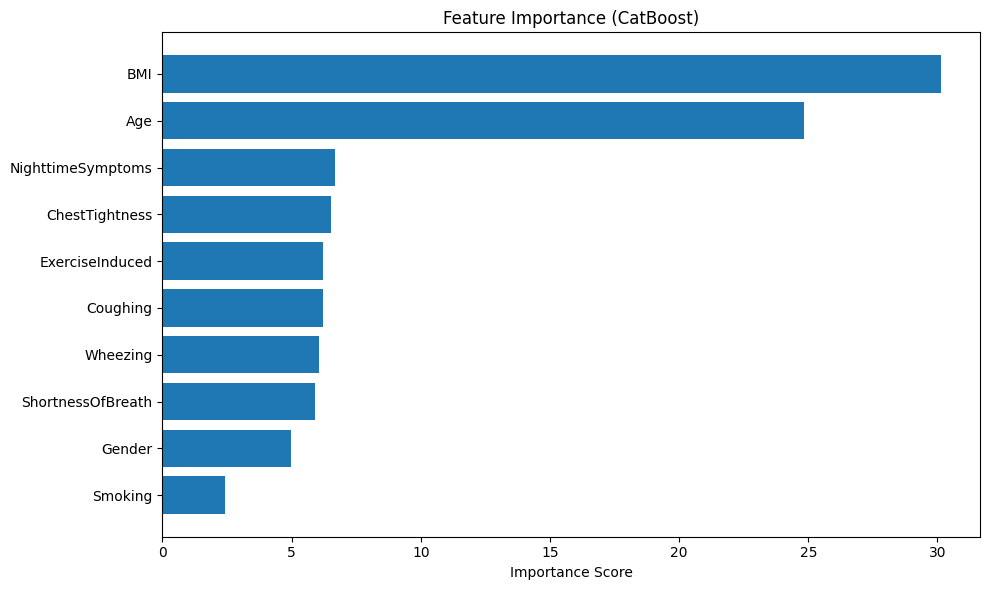

In [ ]:
import matplotlib.pyplot as plt
from catboost import Pool, CatBoostClassifier, cv, CatBoostRegressor, CatBoostRanker, CatBoostError, CatBoost

# Plot feature importance (Top 10)
feature_importances = model.get_feature_importance()
feature_names = X.columns

# Create DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title("Feature Importance (CatBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

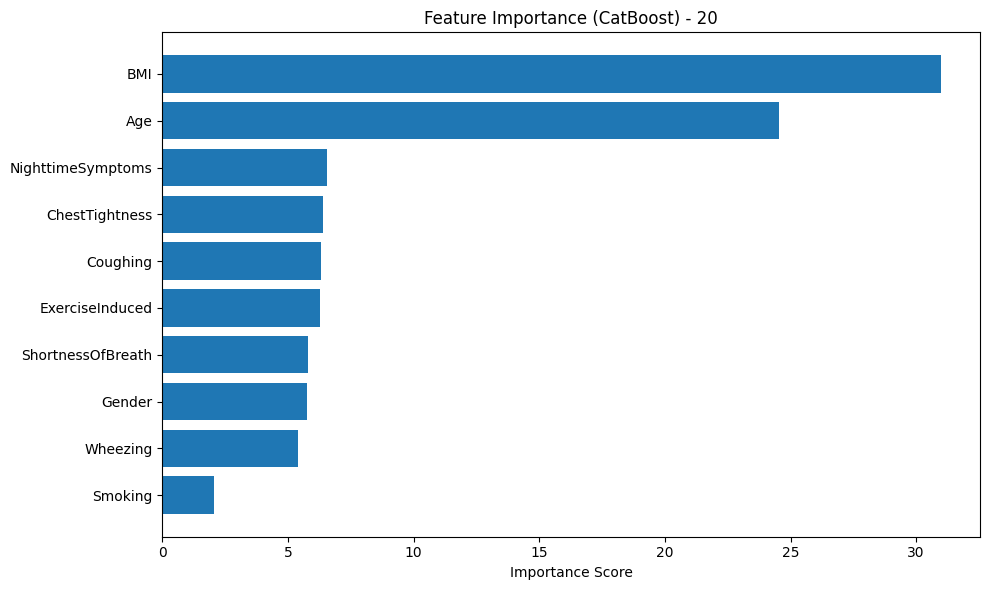

In [ ]:
import matplotlib.pyplot as plt
from catboost import Pool, CatBoostClassifier, cv, CatBoostRegressor, CatBoostRanker, CatBoostError, CatBoost

# Plot feature importance (Top 10)
feature_importances = model.get_feature_importance()
feature_names = X.columns

# Create DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title("Feature Importance (CatBoost) - 20")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.9 MB/s eta 0:00:00


In [ ]:
# Class weights (inverse proportional or heuristic)
# Example: Class 0 = 1, Class 1 (minority) = 10
class_weights = [1, 20]

from catboost import CatBoostClassifier, Pool

# Initialize CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    class_weights=class_weights,
    random_seed=42,
    verbose=100
)

# Train
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

0:	test: 0.6401109	best: 0.6401109 (0)	total: 50.2ms	remaining: 25s
100:	test: 0.9368377	best: 0.9368377 (100)	total: 514ms	remaining: 2.03s
200:	test: 0.9699468	best: 0.9699468 (200)	total: 1.44s	remaining: 2.14s
300:	test: 0.9712863	best: 0.9757610 (234)	total: 2.34s	remaining: 1.54s
400:	test: 0.9760190	best: 0.9777751 (386)	total: 3.06s	remaining: 756ms
499:	test: 0.9725563	best: 0.9777751 (386)	total: 3.96s	remaining: 0us

bestTest = 0.977775132
bestIteration = 386

Shrink model to first 387 iterations.


# LightGBM

In [ ]:
data = pd.read_csv('/content/general.csv')
data

,Age,Gender,BMI,Smoking,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,15.848744,0,0,0,1,0,0,1,0
1,26,1,22.757042,0,1,0,0,1,1,1,0
2,57,0,18.395396,0,1,1,1,0,1,1,0
3,40,1,38.515278,0,1,0,1,1,1,0,0
4,61,0,19.283802,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,29.059613,0,0,1,0,0,0,1,1
7172,18,1,20.740850,0,0,0,0,1,1,0,1
7173,54,0,37.079560,0,1,0,1,1,0,1,1
7174,46,1,23.444712,0,0,1,1,0,1,1,0


In [ ]:
# 3. Handle missing values (optional – based on your dataset)
data.fillna(data.median(numeric_only=True), inplace=True)

In [ ]:
# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

In [ ]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 6. Initialize model
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

model = lgb.LGBMClassifier(is_unbalance=True, random_state=42)

In [ ]:
# 7. Train model
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 298, number of negative: 5442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 347
[LightGBM] [Info] Number of data points in the train set: 5740, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.051916 -> initscore=-2.904808
[LightGBM] [Info] Start training from score -2.904808


LGBMClassifier(is_unbalance=True, random_state=42)

In [ ]:
# 8. Predict earlier was 9th step.
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

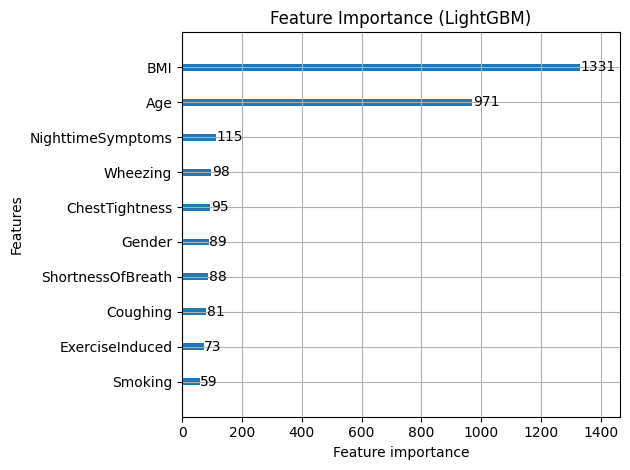

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=10)  # Top 10 features
plt.title("Feature Importance (LightGBM)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC AUC Score: 0.9696690082152637

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1362
           1       0.77      0.96      0.86        74

    accuracy                           0.98      1436
   macro avg       0.88      0.97      0.92      1436
weighted avg       0.99      0.98      0.98      1436



In [ ]:
# 11. Save model
joblib.dump(model, 'asthma_prediction_model_LightGBM_general.pkl')

['asthma_prediction_model_LightGBM_general.pkl']

In [ ]:
Feature --> Feature importance
----------------------------
BMI --> 1331
Age --> 971
Coughing --> 81
ChestTightness --> 95
Gender --> 89
NighttimeSymptoms --> 115
ShortnessOfBreath --> 88
Wheezing --> 98
Smoking --> 59
ExerciseInduced --> 73

In [ ]:
# 3. Handle missing values (optional – based on your dataset)
data.fillna(data.median(numeric_only=True), inplace=True)

# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Initialize model
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

model = lgb.LGBMClassifier(is_unbalance=True, random_state=42)

# 7. Train model
model.fit(X_train, y_train)

# 8. Predict earlier was 9th step.
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=10)  # Top 10 features
plt.title("Feature Importance (LightGBM)")
plt.tight_layout()
plt.show()


# XG-Boost

In [ ]:
# 3. Handle missing values (optional – based on your dataset)
data.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

In [ ]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 5.A --> SMOTENC

categorical_features = ['Gender', 'Smoking', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced']

from imblearn.over_sampling import SMOTENC

# Initialize SMOTENC with the indices of categorical columns
smote_nc = SMOTENC(categorical_features=[X.columns.get_loc(col) for col in categorical_features], random_state=42)

# Apply SMOTENC to the training data (X_train, y_train)
X_train_smnc, y_train_smnc = smote_nc.fit_resample(X_train, y_train)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

data = pd.read_csv('/content/general.csv')
data

# 3. Handle missing values (optional – based on your dataset)
data.fillna(df.median(numeric_only=True), inplace=True)

# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5.A --> SMOTENC

categorical_features = ['Gender', 'Smoking', 'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced']

from imblearn.over_sampling import SMOTENC

# Initialize SMOTENC with the indices of categorical columns
smote_nc = SMOTENC(categorical_features=[X.columns.get_loc(col) for col in categorical_features], random_state=42)

# Apply SMOTENC to the training data (X_train, y_train)
X_train_smnc, y_train_smnc = smote_nc.fit_resample(X_train, y_train)

# 6. Initialize the model (SMOTENC)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=18.29)

# Train the model with resampled data
model.fit(X_train_smnc, y_train_smnc)

# 9. Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 10. Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [ ]:
# 6. Initialize the model (SMOTENC)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=18.29)

# Train the model with resampled data
model.fit(X_train_smnc, y_train_smnc)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:27:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
# 5.1 Extra Step - To handle imbalance
from collections import Counter

# Assume y is your target variable (e.g., y = df['Diagnosis'])
counter = Counter(y)
neg, pos = counter[0], counter[1]  # 0 = Low Risk, 1 = High Risk
ratio_of_neg_to_pos = neg / pos

In [ ]:
print(df['Diagnosis'].value_counts())

Diagnosis
0    6804
1     372
Name: count, dtype: int64


In [ ]:
# 6. Initialize model
# model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# To handle class-Feature Imbalance did some chnages above one is ORIGINAL.
#model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio_of_neg_to_pos)

# After seeing 'Dignosis' count to handle that class imbalance need to do some changes again.
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=18.2)

In [ ]:
# 7. Train model
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:17:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
# 9. Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# 10. Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9143454038997214
ROC-AUC: 0.9814858911775212
Precision: 0.3717277486910995
Recall: 0.9594594594594594
F1 Score: 0.5358490566037736

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95      1362
           1       0.37      0.96      0.54        74

    accuracy                           0.91      1436
   macro avg       0.68      0.94      0.74      1436
weighted avg       0.97      0.91      0.93      1436



In [ ]:
# After adding SMOTENC in Feature imbalance step.

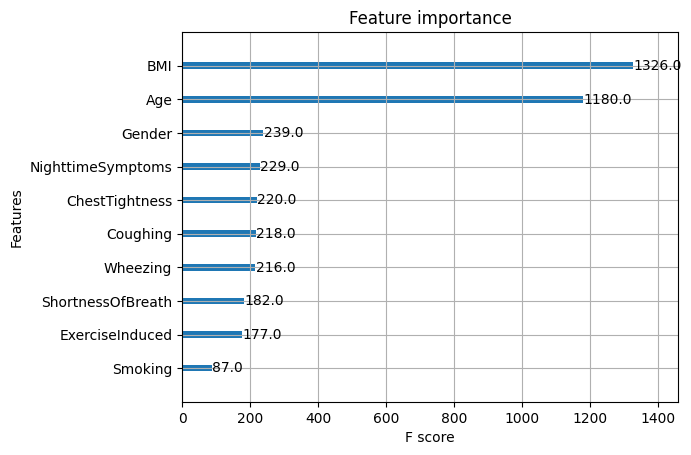

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [ ]:
Feature --> F1 score
----------------------------
BMI --> 1326.0
Age --> 1180.0
Coughing --> 218.0
ChestTightness --> 220.0
Gender --> 239.0
NighttimeSymptoms --> 229.0
ShortnessOfBreath --> 182.0
Wheezing --> 216.0
Smoking --> 87.0
ExerciseInduced --> 177.0

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Split the real data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 3. Train your model on synthetic + real mix
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_sm, y_train_sm)

# 4. Predict on untouched real-world test data
y_pred = model.predict(X_test)


In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into train and test
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


categorical_features = ['Gender', 'Smoking', 'Wheezing', 'ExerciseInduced']

from imblearn.over_sampling import SMOTENC

# Initialize SMOTENC with the indices of categorical columns
smote_nc = SMOTENC(categorical_features=[X.columns.get_loc(col) for col in categorical_features], random_state=42)

# Apply SMOTENC to the training data (X_train, y_train)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

from xgboost import XGBClassifier

# Initialize the model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=18.29)

# Train the model with resampled data
model.fit(X_train_resampled, y_train_resampled)

from sklearn.metrics import accuracy_score

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


In [ ]:
# After adding scale_pos_weight=18.2 in Feature imbalance step.

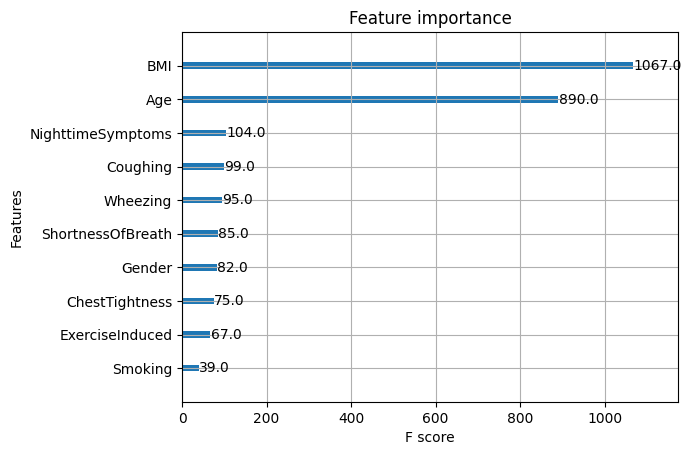

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [ ]:
# After doing changes in Feature imbalance step.

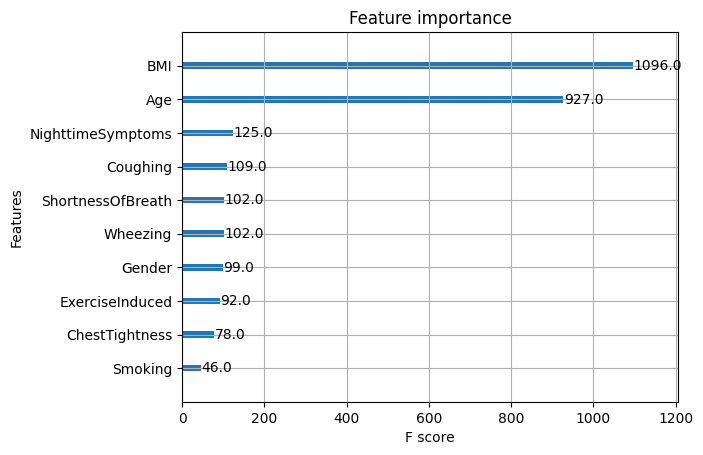

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [ ]:
# We faced this Feature Imbalance problem with :

# 6. Initialize model
# model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Now, I will make few changes in 6th Step to handle Feature-Class Imbalance.

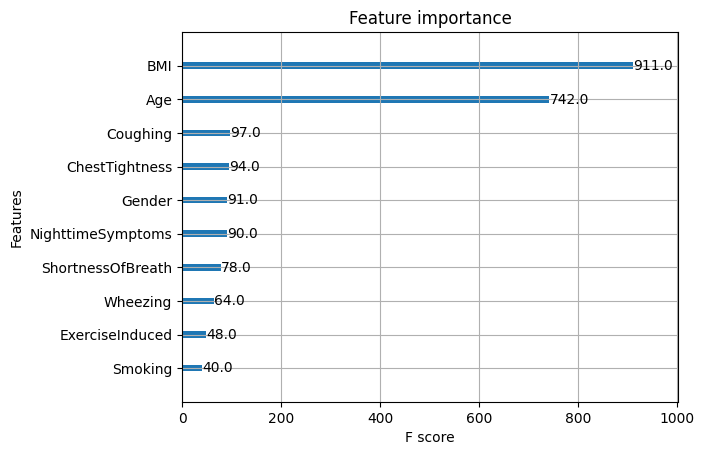

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [ ]:
As you recommended me to go for plot importance graph.

Code :
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

as per that model has given Features vs F1 score graph details are as follows :

Feature --> F1 score
----------------------------
BMI --> 911.0
Age --> 742.0
Coughing --> 97.0
ChestTightness --> 94.0
Gender --> 91.0
NighttimeSymptoms --> 90.0
ShortnessOfBreath --> 78.0
Wheezing --> 64.0
Smoking --> 40.0
ExerciseInduced --> 48.0

this maybe one of the reasons why model is showing Low Risk even if while testing model i invoked High risk conditons but still model has not reconginsed it well.


In [ ]:
# 11. Save model
joblib.dump(model, 'asthma_prediction_model_XGB_general.pkl')

['asthma_prediction_model_XGB_general.pkl']

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Upload/Asthma Dectection Data.csv')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

In [ ]:
# 1. Load Data
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,7421,43,1,0,2,29.059613,0,3.019854,6.119637,8.300960,...,3.125249,5.166032,0,1,0,0,0,1,1,Dr_Confid
7172,7422,18,1,0,1,20.740850,0,5.805180,4.386992,7.731192,...,1.132977,5.509502,0,0,0,1,1,0,1,Dr_Confid
7173,7423,54,0,3,2,37.079560,0,4.735169,8.214064,7.483521,...,1.685962,3.346877,1,0,1,1,0,1,1,Dr_Confid
7174,7424,46,1,0,2,23.444712,0,9.672637,7.362861,6.717272,...,3.481549,1.713274,0,1,1,0,1,1,0,Dr_Confid


In [ ]:
df.drop(columns=['PatientID','DoctorInCharge'], inplace=True)
df

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,...,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,7.388481,...,0,1.369051,4.941206,0,0,1,0,0,1,0
1,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,1.969838,...,0,2.197767,1.702393,1,0,0,1,1,1,0
2,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,1.460593,...,0,1.698011,5.022553,1,1,1,0,1,1,0
3,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,0.581905,...,0,3.032037,2.300159,1,0,1,1,1,0,0
4,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,0.980875,...,0,3.470589,3.067944,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,0,2,29.059613,0,3.019854,6.119637,8.300960,2.483829,...,0,3.125249,5.166032,0,1,0,0,0,1,1
7172,18,1,0,1,20.740850,0,5.805180,4.386992,7.731192,7.733983,...,0,1.132977,5.509502,0,0,0,1,1,0,1
7173,54,0,3,2,37.079560,0,4.735169,8.214064,7.483521,2.794847,...,0,1.685962,3.346877,1,0,1,1,0,1,1
7174,46,1,0,2,23.444712,0,9.672637,7.362861,6.717272,9.448862,...,1,3.481549,1.713274,0,1,1,0,1,1,0


In [ ]:
df.drop(columns=['EducationLevel'], inplace=True)

In [ ]:
df.to_csv('test.csv', index=False)

In [ ]:
data = pd.read_csv('/content/test.csv')
data

,Age,Gender,Ethnicity,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,PollenExposure,...,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,1,15.848744,0,0.894448,5.488696,8.701003,7.388481,2.855578,...,0,1.369051,4.941206,0,0,1,0,0,1,0
1,26,1,2,22.757042,0,5.897329,6.341014,5.153966,1.969838,7.457665,...,0,2.197767,1.702393,1,0,0,1,1,1,0
2,57,0,2,18.395396,0,6.739367,9.196237,6.840647,1.460593,1.448189,...,0,1.698011,5.022553,1,1,1,0,1,1,0
3,40,1,2,38.515278,0,1.404503,5.826532,4.253036,0.581905,7.571845,...,0,3.032037,2.300159,1,0,1,1,1,0,0
4,61,0,0,19.283802,0,4.604493,3.127048,9.625799,0.980875,3.049807,...,0,3.470589,3.067944,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,43,1,0,29.059613,0,3.019854,6.119637,8.300960,2.483829,7.314582,...,0,3.125249,5.166032,0,1,0,0,0,1,1
7172,18,1,0,20.740850,0,5.805180,4.386992,7.731192,7.733983,2.279073,...,0,1.132977,5.509502,0,0,0,1,1,0,1
7173,54,0,3,37.079560,0,4.735169,8.214064,7.483521,2.794847,3.055139,...,0,1.685962,3.346877,1,0,1,1,0,1,1
7174,46,1,0,23.444712,0,9.672637,7.362861,6.717272,9.448862,7.712584,...,1,3.481549,1.713274,0,1,1,0,1,1,0


In [ ]:
# 3. Handle missing values (optional – based on your dataset)
data.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
# 4. Split features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

In [ ]:
# 5. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 7. Initialize model (choose one)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [ ]:
# 7. Initialize model (choose one)
#model = RandomForestClassifier(random_state=42)

In [ ]:
# 8. Train model
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:34:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
# 9. Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# 10. Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9979108635097493
ROC-AUC: 0.9873199190379807
Precision: 1.0
Recall: 0.9594594594594594
F1 Score: 0.9793103448275862

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1362
           1       1.00      0.96      0.98        74

    accuracy                           1.00      1436
   macro avg       1.00      0.98      0.99      1436
weighted avg       1.00      1.00      1.00      1436



In [ ]:
# 11. Save model and scaler
joblib.dump(model, 'asthma_prediction_model_test.pkl')
joblib.dump(scaler, 'scaler_test.pkl')

['scaler_test.pkl']

In [ ]:
# 3. Handle missing values (optional – based on your dataset)
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
# 4. Split features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

In [ ]:
# 5. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 7. Initialize model (choose one)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [ ]:
# 7. Initialize model (choose one)
model = RandomForestClassifier(random_state=42)

In [ ]:
# 8. Train model
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:30:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
# 9. Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# 10. Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9979108635097493
ROC-AUC: 0.9873199190379807
Precision: 1.0
Recall: 0.9594594594594594
F1 Score: 0.9793103448275862

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1362
           1       1.00      0.96      0.98        74

    accuracy                           1.00      1436
   macro avg       1.00      0.98      0.99      1436
weighted avg       1.00      1.00      1.00      1436



In [ ]:
# 11. Save model and scaler
joblib.dump(model, 'asthma_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
# asthma_prediction.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import joblib

# 1. Load Data
#df = pd.read_csv('patient_data.csv')
df

# 2. Drop unnecessary columns
df.drop(columns=['PatientID','DoctorInCharge'], inplace=True)

# 3. Handle missing values (optional – based on your dataset)
df.fillna(df.median(numeric_only=True), inplace=True)

# 4. Split features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# 5. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Initialize model (choose one)
model = RandomForestClassifier(random_state=42)
# model = LogisticRegression()
# model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# 8. Train model
model.fit(X_train, y_train)

# 9. Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 10. Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 11. Save model and scaler
joblib.dump(model, 'asthma_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


ValueError: could not convert string to float: 'Dr_Confid'

# waqi --> http://aqicn.org API_Key --> 0ad37c11dee5eb1eba9f2b0b506b54e296e7e431

In [ ]:
0ad37c11dee5eb1eba9f2b0b506b54e296e7e431

In [ ]:
import requests

def get_aqi_by_place(place_name, api_token):
    # Directly use the place name in the feed query
    url = f"https://api.waqi.info/feed/{place_name}/?token={api_token}"
    response = requests.get(url)
    data = response.json()

    if data["status"] != "ok":
        print("❌ Could not fetch AQI for the given location.")
        return

    aqi = data["data"]["aqi"]
    dominant = data["data"].get("dominentpol", "N/A")
    iaqi = data["data"].get("iaqi", {})

    print(f"📍 Location: {place_name.title()}")
    print(f"🌫 AQI: {aqi}")
    print(f"🏭 Dominant Pollutant: {dominant.upper()}")
    print("📊 Pollutants:")
    for pollutant, value in iaqi.items():
        print(f"  - {pollutant.upper()}: {value['v']}")


In [ ]:
# 🔧 Replace with your actual API token and place name
api_token = "0ad37c11dee5eb1eba9f2b0b506b54e296e7e431"
place_name = "katraj, Pune"

get_aqi_by_place(place_name, api_token)

❌ Could not fetch AQI for the given location.


In [ ]:
import requests

def get_aqi_by_city(city_name, api_key):
    city_url = f"https://api.waqi.info/feed/{city_name}/?token={api_key}"

    try:
        response = requests.get(city_url)
        data = response.json()

        if data['status'] == 'ok':
            city = data['data']['city']['name']
            aqi = data['data']['aqi']
            dominentpol = data['data'].get('dominentpol', 'N/A')
            time = data['data']['time']['s']

            print(f"\n✅ Real-Time AQI for {city}")
            print(f"AQI: {aqi}")
            print(f"Dominant Pollutant: {dominentpol}")
            print(f"Last Updated: {time}")
        else:
            print(f"❌ API Error: {data.get('data', 'Unknown error')}")

    except Exception as e:
        print("❌ Exception occurred:", str(e))


# Example usage
your_api_key = "0ad37c11dee5eb1eba9f2b0b506b54e296e7e431"
city_name = "delhi"  # You can try other city names like 'bangalore', 'mumbai', etc.

get_aqi_by_city(city_name, your_api_key)



✅ Real-Time AQI for Major Dhyan Chand National Stadium, Delhi, Delhi, India
AQI: 137
Dominant Pollutant: pm25
Last Updated: 2025-05-07 18:00:00


In [ ]:
import requests

def get_aqi(location, api_key):
    """
    Fetch AQI data for a given location.
    The location can be just a city or a full address like 'Place, City, Country'.
    """
    api_url = f"https://api.waqi.info/feed/{location}/?token={api_key}"

    try:
        response = requests.get(api_url)
        data = response.json()

        if data['status'] == 'ok':
            city_full = data['data']['city']['name']
            aqi = data['data']['aqi']
            dominentpol = data['data'].get('dominentpol', 'N/A')
            time = data['data']['time']['s']

            print(f"\n✅ Real-Time AQI for {city_full}")
            print(f"AQI: {aqi}")
            print(f"Dominant Pollutant: {dominentpol}")
            print(f"Last Updated: {time}")
        else:
            print(f"❌ API Error: {data.get('data', 'Unknown error')}")

    except Exception as e:
        print("❌ Exception occurred:", str(e))


# Example usage
your_api_key = "0ad37c11dee5eb1eba9f2b0b506b54e296e7e431"

# Input can be just a city OR a full address
user_input_location = input("Enter location (e.g., 'Delhi' or 'Shibuya Station, Tokyo, Japan'): ").strip()

get_aqi(user_input_location, your_api_key)


Enter location (e.g., 'Delhi' or 'Shibuya Station, Tokyo, Japan'): Katraj, Pune
❌ API Error: Unknown station


In [ ]:
import requests

def get_aqi_by_location(place, city, country, api_key):
    # Construct location string for the query
    location_query = f"{place}, {city}, {country}"
    api_url = f"https://api.waqi.info/feed/{location_query}/?token={api_key}"

    try:
        response = requests.get(api_url)
        data = response.json()

        if data['status'] == 'ok':
            city_full = data['data']['city']['name']
            aqi = data['data']['aqi']
            dominentpol = data['data'].get('dominentpol', 'N/A')
            time = data['data']['time']['s']

            print(f"\n✅ Real-Time AQI for {city_full}")
            print(f"AQI: {aqi}")
            print(f"Dominant Pollutant: {dominentpol}")
            print(f"Last Updated: {time}")
        else:
            print(f"❌ API Error: {data.get('data', 'Unknown error')}")

    except Exception as e:
        print("❌ Exception occurred:", str(e))


# Example usage
your_api_key = "0ad37c11dee5eb1eba9f2b0b506b54e296e7e431"
place = "Katraj"
city = "Pune"
country = "India"

get_aqi_by_location(place, city, country, your_api_key)


❌ API Error: Unknown station


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
city = "delhi"
api_token = "your_api_token_here"

get_aqi(city, api_token)

In [ ]:
import requests

def get_aqi(city_name, token):
    base_url = "https://api.waqi.info/feed/{}/?token={}".format(city_name, token)

    response = requests.get(base_url)
    data = response.json()

    if data["status"] == "ok":
        aqi = data["data"]["aqi"]
        dominant_pollutant = data["data"]["dominentpol"]
        iaqi = data["data"]["iaqi"]

        print(f"\n📍 City: {city_name}")
        print(f"🟠 AQI: {aqi}")
        print(f"🏭 Main Pollutant: {dominant_pollutant.upper()}\n")
        print("📊 Pollutant Levels:")
        for pollutant, value in iaqi.items():
            print(f"  - {pollutant.upper()}: {value['v']}")

    else:
        print(f"❌ Error: {data.get('data', 'Unable to fetch AQI.')}")

In [ ]:
AQI API Key --> 8b9e3867-397d-4c72-bb89-b4e1f1919e60

In [ ]:
import requests

def get_city_aqi(city, state, country, api_key):
    url = f"http://api.airvisual.com/v2/city?city={city}&state={state}&country={country}&key={api_key}"
    response = requests.get(url)
    data = response.json()

    if data['status'] != 'success':
        return f"Error: {data.get('data', {}).get('message', 'Unknown error')}"

    pollution = data['data']['current']['pollution']
    weather = data['data']['current']['weather']

    result = {
        'City': city,
        'State': state,
        'Country': country,
        'AQI (US)': pollution['aqius'],
        'Main Pollutant': pollution['mainus'],
        'Temperature (°C)': weather['tp'],
        'Humidity (%)': weather['hu'],
        'Wind Speed (m/s)': weather['ws']
    }

    return result


In [ ]:
#api_key = "your_iqair_api_key_here"
api_key = "8b9e3867-397d-4c72-bb89-b4e1f1919e60"
print(get_city_aqi("Pune", "Maharashtra", "India", api_key))

{'City': 'Pune', 'State': 'Maharashtra', 'Country': 'India', 'AQI (US)': 55, 'Main Pollutant': 'p2', 'Temperature (°C)': 32, 'Humidity (%)': 28, 'Wind Speed (m/s)': 6.8}


In [ ]:
api_key = "8b9e3867-397d-4c72-bb89-b4e1f1919e60"
print(get_city_aqi("Mumbai", "Maharashtra", "India", api_key))

{'City': 'Mumbai', 'State': 'Maharashtra', 'Country': 'India', 'AQI (US)': 71, 'Main Pollutant': 'p2', 'Temperature (°C)': 29, 'Humidity (%)': 69, 'Wind Speed (m/s)': 6.42}


In [ ]:
api_key = "8b9e3867-397d-4c72-bb89-b4e1f1919e60"
print(get_city_aqi("Delhi", "Delhi", "India", api_key))

{'City': 'Delhi', 'State': 'Delhi', 'Country': 'India', 'AQI (US)': 151, 'Main Pollutant': 'p2', 'Temperature (°C)': 33, 'Humidity (%)': 43, 'Wind Speed (m/s)': 5.66}


#Openweather Map

In [ ]:
AQI API Key : 99c7429521d000ac8c405ffe6f64bc7c

In [ ]:
import requests

def get_aqi_info(city_name, api_key):
    # Step 1: Get the coordinates (lat, lon) of the city
    geocoding_url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_name}&limit=1&appid={api_key}"
    geo_response = requests.get(geocoding_url).json()

    if not geo_response:
        return f"Location '{city_name}' not found."

    lat = geo_response[0]['lat']
    lon = geo_response[0]['lon']

    # Step 2: Get AQI data for those coordinates
    aqi_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={api_key}"
    aqi_response = requests.get(aqi_url).json()

    # Parse and format the response
    aqi_data = aqi_response['list'][0]
    aqi_level = aqi_data['main']['aqi']
    components = aqi_data['components']

    aqi_description = {
        1: "Good",
        2: "Fair",
        3: "Moderate",
        4: "Poor",
        5: "Very Poor"
    }

    result = {
        "City": city_name,
        "Latitude": lat,
        "Longitude": lon,
        "AQI Level": aqi_level,
        "AQI Status": aqi_description.get(aqi_level, "Unknown"),
        "Components (μg/m³)": components
    }

    return result


In [ ]:
api_key = "your_api_key_here"
city = "Pune"
print(get_aqi_info(city, api_key))

KeyError: 0